In [14]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import cv2

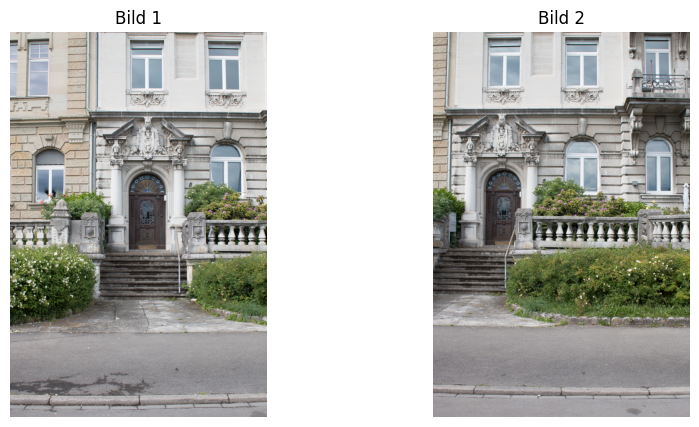

In [15]:
# TODO: Bilder einsetzen

image1 = plt.imread("Bilder/Set1_Img1.jpg").astype(float)
image2 = plt.imread("Bilder/Set1_Img2.jpg").astype(float)

# Falls Bilder als uint8 geladen werden
if image1.max() > 1:
    image1 = image1 / 255

if image2.max() > 1:
    image2 = image2 / 255

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image1)
axes[0].set_title("Bild 1")
axes[0].axis("off")

axes[1].imshow(image2)
axes[1].set_title("Bild 2")
axes[1].axis("off")

plt.show()

In [16]:
def compute_homography(bi, bj):
    M = []

    for i in range(len(bi)):
        x, y = bi[i]
        u, v = bj[i]

        M.append([x, y, 1, 0, 0, 0, -(u*x), -(u*y), -u])
        M.append([0, 0, 0, x, y, 1, -(v*x), -(v*y), -v])

    M = np.array(M)

    # SVD von M
    U, S, Vt = np.linalg.svd(M)

    # Lösung ist der Singulärvektor zum kleinsten Singulärwert
    h = Vt[-1]

    H = np.array([
        [h[0], h[1], h[2]],
        [h[3], h[4], h[5]],
        [h[6], h[7], h[8]]
    ])

    # Normieren, sodass H[2,2] = 1
    H = H / H[2, 2]

    return H

In [17]:
bi = np.array([
    [355, 563],  # Tür Mitte unten
    [275, 305],  # Gesicht Nase Tür links
    [440, 305],  # Gesicht Nase Tür rechts
    [560, 339],  # Fenster unten rechts / Fenster 2 unten Mitte
    [355, 148],  # Fenster über Tür
    [564, 233],  # Säule über Fenster
    [469, 391],  # Hausnummer
    [597, 67]    # Rechte Ecke Fenster

], dtype=float)

bj = np.array([
    [184, 553],  # Tür Mitte unten
    [95, 297],   # Gesicht Nase Tür links
    [257, 297],  # Gesicht Nase Tür rechts
    [388, 326],  # Fenster 2 unten Mitte
    [184, 140],  # Fenster über Tür
    [387, 223],  # Säule über Fenster
    [289, 382],  # Hausnummer
    [430, 56]    # Rechte Ecke Fenster
], dtype=float)

bi_false = np.array([
    [355, 563],  # Tür Mitte unten
    [275, 305],  # Gesicht Nase Tür links
    [440, 305],  # Gesicht Nase Tür rechts
    [560, 339],  # Fenster unten rechts / Fenster 2 unten Mitte
    [355, 148],  # Fenster über Tür
    [564, 233],  # Säule über Fenster
    [469, 391],  # Hausnummer
    [597, 67],    # Rechte Ecke Fenster
    [200, 200],
    [600, 333],
    [123, 456]

], dtype=float)

bj_false = np.array([
    [184, 553],  # Tür Mitte unten
    [95, 297],   # Gesicht Nase Tür links
    [257, 297],  # Gesicht Nase Tür rechts
    [388, 326],  # Fenster 2 unten Mitte
    [184, 140],  # Fenster über Tür
    [387, 223],  # Säule über Fenster
    [289, 382],  # Hausnummer
    [430, 56],    # Rechte Ecke Fenster
    [200, 200],    # Falscher Punkt
    [450, 10],
    [300, 400]
], dtype=float)

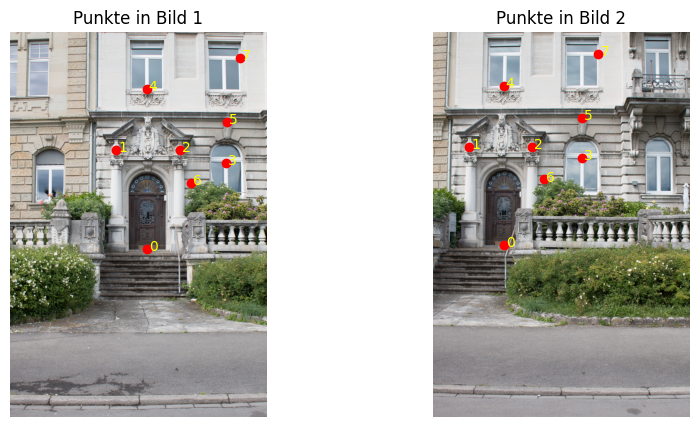

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image1)
axes[0].scatter(bi[:,0], bi[:,1], c="red")

for i, (x, y) in enumerate(bi):
    axes[0].text(x + 5, y + 5, str(i), color="yellow")

axes[0].set_title("Punkte in Bild 1")
axes[0].axis("off")


axes[1].imshow(image2)
axes[1].scatter(bj[:,0], bj[:,1], c="red")

for i, (x, y) in enumerate(bj):
    axes[1].text(x + 5, y + 5, str(i), color="yellow")

axes[1].set_title("Punkte in Bild 2")
axes[1].axis("off")

plt.show()

In [19]:
bi_train = bi[:6]
bj_train = bj[:6]

bi_test = bi[6:]
bj_test = bj[6:]

H12 = compute_homography(bi_train, bj_train)

print("H12:")
print(H12)
print("H[2,2] =", H12[2,2])

H12:
[[ 1.14280207e+00  1.39095225e-02 -2.17563618e+02]
 [ 3.74229739e-02  1.07620734e+00 -2.35437537e+01]
 [ 1.84662430e-04  2.05572038e-05  1.00000000e+00]]
H[2,2] = 1.0


In [20]:
def transform_points(points, H):

    transformed = []

    for p in points:
        x, y = p

        q = H @ np.array([x, y, 1])
        q = q / q[2]

        transformed.append([q[0], q[1]])

    return np.array(transformed)

def mean_error(points_true, points_estimated):

    distances = []

    for p_true, p_est in zip(points_true, points_estimated):

        d = np.sqrt(
            (p_true[0] - p_est[0])**2 +
            (p_true[1] - p_est[1])**2
        )

        distances.append(d)

    return np.mean(distances), np.array(distances)

In [21]:
bj_estimated = transform_points(bi_test, H12)

mean_dist, distances = mean_error(bj_test, bj_estimated)

print("Geschätzte Punkte:")
print(bj_estimated)

print("Echte Punkte:")
print(bj_test)

print("Einzelfehler:")
print(distances)

print("Mittlerer euklidischer Abstand:")
print(mean_dist)

Geschätzte Punkte:
[[295.84870841 378.9400783 ]
 [418.8668953   63.78402884]]
Echte Punkte:
[[289. 382.]
 [430.  56.]]
Einzelfehler:
[ 7.50119509 13.58444424]
Mittlerer euklidischer Abstand:
10.542819664778488


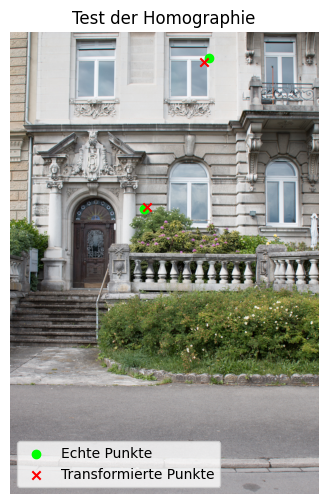

In [22]:
plt.figure(figsize=(8, 6))
plt.imshow(image2)

plt.scatter(
    bj_test[:,0],
    bj_test[:,1],
    c="lime",
    label="Echte Punkte"
)

plt.scatter(
    bj_estimated[:,0],
    bj_estimated[:,1],
    c="red",
    marker="x",
    label="Transformierte Punkte"
)

plt.legend()
plt.title("Test der Homographie")
plt.axis("off")
plt.show()

In [23]:
def image_rectification(image, H, out_h, out_w):

    H_inv = np.linalg.inv(H)

    if len(image.shape) == 2:
        rectified = np.zeros((out_h, out_w), dtype=image.dtype)
    else:
        rectified = np.zeros((out_h, out_w, image.shape[2]), dtype=image.dtype)

    for y_ref in range(out_h):
        for x_ref in range(out_w):

            p_ref = np.array([x_ref, y_ref, 1])

            p_img = H_inv @ p_ref
            p_img = p_img / p_img[2]

            x = p_img[0]
            y = p_img[1]

            x_n = int(np.round(x))
            y_n = int(np.round(y))

            if (0 <= x_n < image.shape[1] and
                0 <= y_n < image.shape[0]):

                rectified[y_ref, x_ref] = image[y_n, x_n]

    return rectified

In [24]:
def transformed_corners(image, H):

    h, w = image.shape[:2]

    corners = np.array([
        [0, 0],
        [w, 0],
        [w, h],
        [0, h]
    ], dtype=float)

    return transform_points(corners, H)


In [25]:
corners1_t = transformed_corners(image1, H12)

h2, w2 = image2.shape[:2]

corners2 = np.array([
    [0, 0],
    [w2, 0],
    [w2, h2],
    [0, h2]
], dtype=float)

all_corners = np.vstack([corners1_t, corners2])

xmin = np.min(all_corners[:,0])
xmax = np.max(all_corners[:,0])

ymin = np.min(all_corners[:,1])
ymax = np.max(all_corners[:,1])

PAN_WIDTH = int(np.ceil(xmax - xmin))
PAN_HEIGHT = int(np.ceil(ymax - ymin))

tx = -xmin
ty = -ymin

T = np.array([
    [1, 0, tx],
    [0, 1, ty],
    [0, 0, 1]
])

In [26]:
H1_shifted = T @ H12
H2_shifted = T
image1_registered = image_rectification(
    image1,
    H1_shifted,
    PAN_HEIGHT,
    PAN_WIDTH
)

image2_registered = image_rectification(
    image2,
    H2_shifted,
    PAN_HEIGHT,
    PAN_WIDTH
)
registered = np.zeros_like(image1_registered)

for y in range(PAN_HEIGHT):
    for x in range(PAN_WIDTH):

        p1 = image1_registered[y, x]
        p2 = image2_registered[y, x]

        valid1 = np.sum(p1) > 0
        valid2 = np.sum(p2) > 0

        if valid1 and not valid2:
            registered[y, x] = p1

        elif valid2 and not valid1:
            registered[y, x] = p2

        elif valid1 and valid2:
            registered[y, x] = 0.5 * p1 + 0.5 * p2

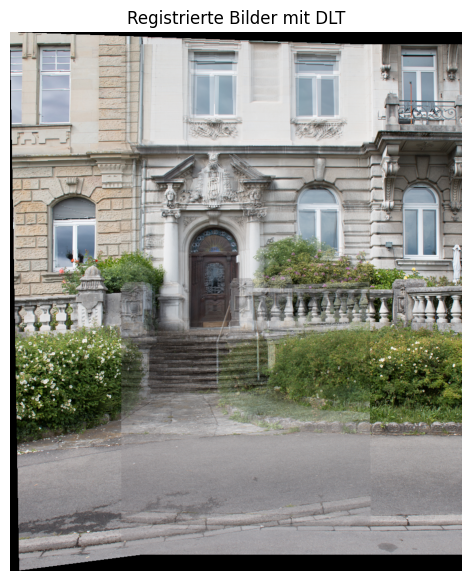

In [27]:
plt.figure(figsize=(12, 7))
plt.imshow(registered)
plt.title("Registrierte Bilder mit DLT")
plt.axis("off")
plt.show()

In [28]:
def normalize_points(points):

    mean_x = np.mean(points[:,0])
    mean_y = np.mean(points[:,1])

    std_x = np.std(points[:,0])
    std_y = np.std(points[:,1])

    T = np.array([
        [1/std_x, 0, -mean_x/std_x],
        [0, 1/std_y, -mean_y/std_y],
        [0, 0, 1]
    ])

    points_norm = transform_points(points, T)

    return points_norm, T

def compute_homography_normalized(bi, bj):

    bi_norm, T = normalize_points(bi)
    bj_norm, T_prime = normalize_points(bj)

    H_norm = compute_homography(bi_norm, bj_norm)

    H = np.linalg.inv(T_prime) @ H_norm @ T

    H = H / H[2,2]

    return H


In [29]:
H12_norm = compute_homography_normalized(
    bi_train,
    bj_train
)

print("H12 normiert:")
print(H12_norm)
print("H[2,2] =", H12_norm[2,2])

H12 normiert:
[[ 1.02546223e+00  3.53301293e-03 -1.84619696e+02]
 [-7.79437232e-04  9.93968677e-01 -4.62204847e+00]
 [ 3.85320155e-05 -2.02418408e-05  1.00000000e+00]]
H[2,2] = 1.0


In [30]:
bj_estimated_norm = transform_points(bi_test, H12_norm)

mean_dist_norm, distances_norm = mean_error(
    bj_test,
    bj_estimated_norm
)

print("Geschätzte Punkte mit normierter DLT:")
print(bj_estimated_norm)

print("Echte Punkte:")
print(bj_test)

print("Einzelfehler:")
print(distances_norm)

print("Mittlerer Fehler normale DLT:")
print(mean_dist)

print("Mittlerer Fehler normierte DLT:")
print(mean_dist_norm)


Geschätzte Punkte mit normierter DLT:
[[294.71013958 379.79657118]
 [418.75304757  60.2052413 ]]
Echte Punkte:
[[289. 382.]
 [430.  56.]]
Einzelfehler:
[ 6.12052224 12.0074141 ]
Mittlerer Fehler normale DLT:
10.542819664778488
Mittlerer Fehler normierte DLT:
9.063968170730622


In [31]:
corners1_t = transformed_corners(image1, H12_norm)

all_corners = np.vstack([corners1_t, corners2])

xmin = np.min(all_corners[:,0])
xmax = np.max(all_corners[:,0])

ymin = np.min(all_corners[:,1])
ymax = np.max(all_corners[:,1])

PAN_WIDTH = int(np.ceil(xmax - xmin))
PAN_HEIGHT = int(np.ceil(ymax - ymin))

tx = -xmin
ty = -ymin

T_canvas = np.array([
    [1, 0, tx],
    [0, 1, ty],
    [0, 0, 1]
])

H1_shifted_norm = T_canvas @ H12_norm
H2_shifted_norm = T_canvas

In [32]:
image1_registered_norm = image_rectification(
    image1,
    H1_shifted_norm,
    PAN_HEIGHT,
    PAN_WIDTH
)

image2_registered_norm = image_rectification(
    image2,
    H2_shifted_norm,
    PAN_HEIGHT,
    PAN_WIDTH
)

In [33]:
registered_norm = np.zeros_like(image1_registered_norm)

for y in range(PAN_HEIGHT):
    for x in range(PAN_WIDTH):

        p1 = image1_registered_norm[y, x]
        p2 = image2_registered_norm[y, x]

        valid1 = np.sum(p1) > 0
        valid2 = np.sum(p2) > 0

        if valid1 and not valid2:
            registered_norm[y, x] = p1

        elif valid2 and not valid1:
            registered_norm[y, x] = p2

        elif valid1 and valid2:
            registered_norm[y, x] = 0.5 * p1 + 0.5 * p2

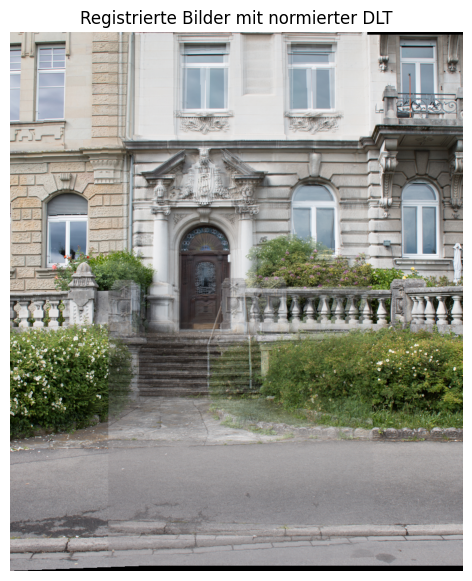

In [34]:
plt.figure(figsize=(12, 7))
plt.imshow(registered_norm)
plt.title("Registrierte Bilder mit normierter DLT")
plt.axis("off")
plt.show()

In [35]:
def ransac_homography_normalized(bi, bj, iterations=1000, threshold=50):
    """
    RANSAC für Homographie-Schätzung mit normierter DLT.

    bi: Punkte in Bild 1
    bj: korrespondierende Punkte in Bild 2
    threshold: maximaler Fehler für Inlier
    """

    n = len(bi)

    best_H = None
    best_inliers = None
    best_error = np.inf

    indices = np.arange(n)

    for k in range(iterations):

        # 1. Zufällig 4 Korrespondenzen auswählen
        sample_idx = np.random.choice(indices, 4, replace=False)

        bi_sample = bi[sample_idx]
        bj_sample = bj[sample_idx]

        # 2. Homographie mit normierter DLT berechnen
        try:
            H = compute_homography_normalized(bi_sample, bj_sample)
        except:
            continue

        # 3. Alle Punkte transformieren
        bj_estimated = transform_points(bi, H)

        # 4. Fehler berechnen
        errors = np.sqrt(
            (bj[:,0] - bj_estimated[:,0])**2 +
            (bj[:,1] - bj_estimated[:,1])**2
        )

        # 5. Consensus set bestimmen
        inliers = errors < threshold

        num_inliers = np.sum(inliers)

        if num_inliers > 0:
            mean_inlier_error = np.mean(errors[inliers])
        else:
            mean_inlier_error = np.inf

        # 6. Bestes Modell speichern
        if best_inliers is None:
            update = True
        else:
            update = (
                num_inliers > np.sum(best_inliers)
                or
                (num_inliers == np.sum(best_inliers)
                 and mean_inlier_error < best_error)
            )

        if update:
            best_H = H
            best_inliers = inliers
            best_error = mean_inlier_error

    # Finale Homographie nochmal mit allen Inliern berechnen
    if best_inliers is not None and np.sum(best_inliers) >= 4:
        best_H = compute_homography_normalized(
            bi[best_inliers],
            bj[best_inliers]
        )

        bj_estimated = transform_points(bi[best_inliers], best_H)

        best_error, _ = mean_error(
            bj[best_inliers],
            bj_estimated
        )

    return best_H, best_inliers, best_error

In [36]:
H_ransac, inliers, ransac_error = ransac_homography_normalized(
    bi,
    bj,
    iterations=1000,
    threshold=14
)
print("RANSAC Homographie:")
print(H_ransac)

print("Consensus set:")
print(inliers)

print("Anzahl Inlier:")
print(np.sum(inliers))

print("Mittlerer Fehler der Inlier:")
print(ransac_error)

RANSAC Homographie:
[[ 1.03189425e+00  9.45007071e-03 -1.86634609e+02]
 [-1.05520852e-02  1.03888610e+00 -8.85624750e+00]
 [ 5.95536833e-06  6.46550370e-05  1.00000000e+00]]
Consensus set:
[ True  True  True  True  True  True  True  True]
Anzahl Inlier:
8
Mittlerer Fehler der Inlier:
4.69207930041204


In [37]:
H_ransac, inliers, ransac_error = ransac_homography_normalized(
    bi_false,
    bj_false,
    iterations=1000,
    threshold=14
)
print("RANSAC Homographie:")
print(H_ransac)

print("Consensus set:")
print(inliers)

print("Anzahl Inlier:")
print(np.sum(inliers))

print("Mittlerer Fehler der Inlier:")
print(ransac_error)

real_H = compute_homography_normalized(bi, bj)
print("Echte Homographie:")
print(real_H)

RANSAC Homographie:
[[ 1.03189425e+00  9.45007071e-03 -1.86634609e+02]
 [-1.05520852e-02  1.03888610e+00 -8.85624750e+00]
 [ 5.95536833e-06  6.46550370e-05  1.00000000e+00]]
Consensus set:
[ True  True  True  True  True  True  True  True False False False]
Anzahl Inlier:
8
Mittlerer Fehler der Inlier:
4.69207930041204
Echte Homographie:
[[ 1.03189425e+00  9.45007071e-03 -1.86634609e+02]
 [-1.05520852e-02  1.03888610e+00 -8.85624750e+00]
 [ 5.95536833e-06  6.46550370e-05  1.00000000e+00]]


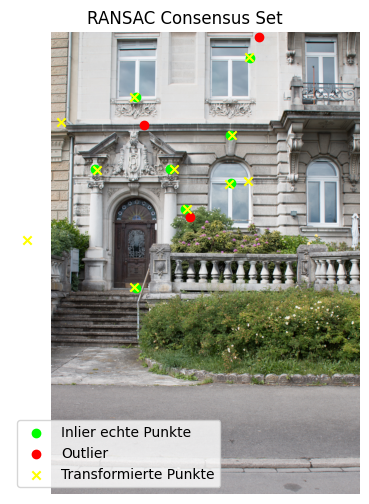

In [38]:
bj_estimated_ransac = transform_points(bi_false, H_ransac)

plt.figure(figsize=(8, 6))
plt.imshow(image2)

plt.scatter(
    bj_false[inliers,0],
    bj_false[inliers,1],
    c="lime",
    label="Inlier echte Punkte"
)

plt.scatter(
    bj_false[~inliers,0],
    bj_false[~inliers,1],
    c="red",
    label="Outlier"
)

plt.scatter(
    bj_estimated_ransac[:,0],
    bj_estimated_ransac[:,1],
    c="yellow",
    marker="x",
    label="Transformierte Punkte"
)

plt.legend()
plt.title("RANSAC Consensus Set")
plt.axis("off")
plt.show()

In [39]:
import sift
# Falls image1/image2 mit plt.imread geladen wurden und Werte in [0,1] haben:
image1_u8 = (np.clip(image1, 0, 1) * 255).astype(np.uint8)
image2_u8 = (np.clip(image2, 0, 1) * 255).astype(np.uint8)

# plt.imread liefert RGB, daher RGB2GRAY
image1_g = cv2.cvtColor(image1_u8, cv2.COLOR_RGB2GRAY)
image2_g = cv2.cvtColor(image2_u8, cv2.COLOR_RGB2GRAY)

print(image1_g.dtype, image1_g.shape, image1_g.min(), image1_g.max())
print(image2_g.dtype, image2_g.shape, image2_g.min(), image2_g.max())

uint8 (1000, 667) 0 253
uint8 (1000, 667) 0 254


4348 key points detected.
4505 key points detected.


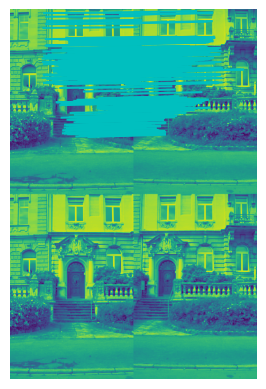

In [40]:
location_list_img1 , descriptor_list_img1 = sift.detect_and_compute (image1_g)
location_list_img2 , descriptor_list_img2 = sift.detect_and_compute (image2_g)
matches = sift.match_twosided( descriptor_list_img1 , descriptor_list_img2)
sift.plot_matches(image1_g, image2_g, location_list_img1 , location_list_img2 , matches , True)

In [56]:
def correspondences_from_matches(location_list_img1,
                                 location_list_img2,
                                 matches):

    bi = []
    bj = []

    for i in range(len(matches)):

        j = matches[i]

        # In this SIFT implementation: 0 means no match
        if j > 0:
            x1, y1 = location_list_img1[i, 0], location_list_img1[i, 1]
            x2, y2 = location_list_img2[int(j), 0], location_list_img2[int(j), 1]

            bi.append([x1, y1])
            bj.append([x2, y2])

    return np.array(bi, dtype=float), np.array(bj, dtype=float)

bi_sift, bj_sift = correspondences_from_matches(
    location_list_img1,
    location_list_img2,
    matches
)

print("Number of SIFT correspondences:", len(bi_sift))
print(bi_sift[:10])
print(bj_sift[:10])

Number of SIFT correspondences: 625
[[175.82698059 265.40081787]
 [176.77510071 369.38882446]
 [177.59970093 283.86312866]
 [180.57862854  99.56417847]
 [181.06352234 227.22608948]
 [181.89416504 353.35668945]
 [183.37565613 295.85549927]
 [183.79917908 397.48574829]
 [184.15034485 250.05525208]
 [184.1917572   19.46751022]]
[[ 10.17597294 259.06466675]
 [ 10.34150982 361.1706543 ]
 [ 12.087327   277.46914673]
 [ 17.93482971  95.64202118]
 [ 13.04286098 221.52912903]
 [ 15.44471836 345.43292236]
 [ 17.89323044 288.9776001 ]
 [ 16.82621002 388.71643066]
 [ 17.91776085 243.81694031]
 [ 23.22638512  16.39762688]]


In [57]:
H_sift, inliers_sift, mse_sift = ransac_homography_normalized(
    bi_sift,
    bj_sift,
    iterations=1000,
    threshold=50
)


In [60]:

print("Homographie aus SIFT + RANSAC:")
print(H_sift)

print("Anzahl Korrespondenzen:")
print(len(bi_sift))

print("Anzahl Inlier:")
print(np.sum(inliers_sift))

print("Mittlerer quadratischer Fehler:")
print(mse_sift)

real_H = compute_homography_normalized(bi, bj)
print("Echte Homographie:")
print(real_H)

Homographie aus SIFT + RANSAC:
[[ 8.91670258e-01 -1.28099994e-01 -1.10414644e+02]
 [-4.87810516e-02  1.00886282e+00  1.25006228e+00]
 [-1.38467862e-04  9.07962158e-05  1.00000000e+00]]
Anzahl Korrespondenzen:
625
Anzahl Inlier:
622
Mittlerer quadratischer Fehler:
10.51967445242292
Echte Homographie:
[[ 1.03189425e+00  9.45007071e-03 -1.86634609e+02]
 [-1.05520852e-02  1.03888610e+00 -8.85624750e+00]
 [ 5.95536833e-06  6.46550370e-05  1.00000000e+00]]


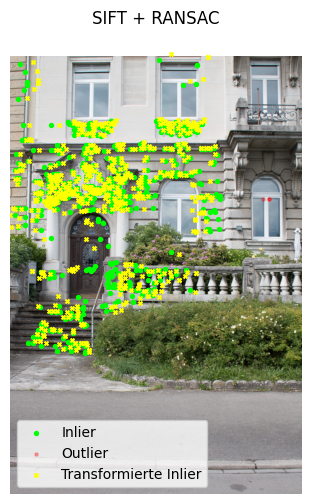

In [59]:
bj_sift_est = transform_points(bi_sift, H_sift)

plt.figure(figsize=(8,6))
plt.imshow(image2)

plt.scatter(
    bj_sift[inliers_sift,0],
    bj_sift[inliers_sift,1],
    c="lime",
    s=8,
    label="Inlier"
)

plt.scatter(
    bj_sift[~inliers_sift,0],
    bj_sift[~inliers_sift,1],
    c="red",
    s=5,
    alpha=0.3,
    label="Outlier"
)

plt.scatter(
    bj_sift_est[inliers_sift,0],
    bj_sift_est[inliers_sift,1],
    c="yellow",
    marker="x",
    s=8,
    label="Transformierte Inlier"
)

plt.legend()
plt.axis("off")
plt.title("SIFT + RANSAC")
plt.show()